In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
# Load official UCI dataset
df = pd.read_csv("bank-full.csv", sep=';')

print("Shape:", df.shape)
print(df.head())
print(df.info())


Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (to

In [ ]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Duplicate rows: 0

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
# 5. Handle 'unknown' Values in Categorical Columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace('unknown', df[col].mode()[0])


In [ ]:
# 6. Convert Target Variable to Binary
df['y'] = df['y'].map({'yes': 1, 'no': 0})


In [ ]:
# 7. Separate Categorical and Numerical Features
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


Categorical: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')
Numerical: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'y'],
      dtype='object')


In [ ]:
# 8. Apply One-Hot Encoding to Categorical Variables
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("After Encoding Shape:", df_encoded.shape)


After Encoding Shape: (45211, 40)


In [ ]:
# 9. Scale Numerical Features Using StandardScaler
scaler = StandardScaler()

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])


In [ ]:
# 10. Define Feature Matrix (X) and Target Vector (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']


In [ ]:
# 11. Perform Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (36168, 39)
Test set: (9043, 39)


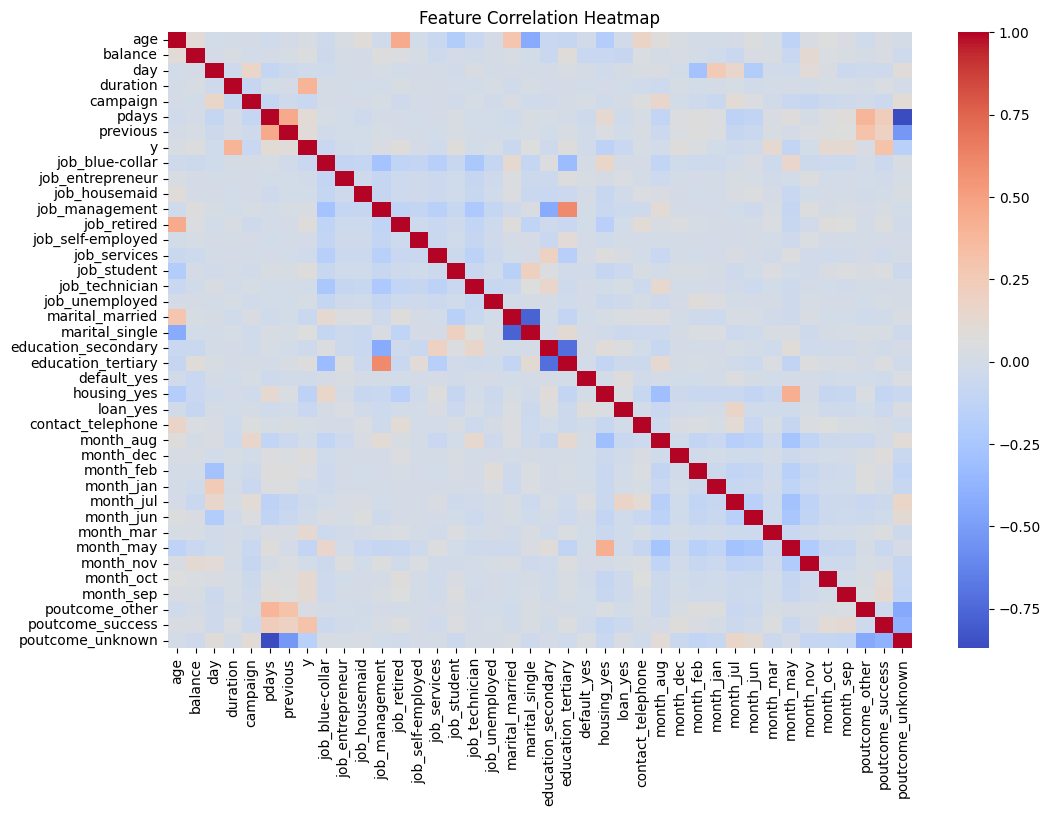

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))

corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

`Week 2 `

In [ ]:
# ===============================
# WEEK 2 – MODEL DEVELOPMENT
# ===============================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# -------------------------------
# Decision Tree
# -------------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train.astype(int))

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

print("===== Decision Tree Results ====")
print("Accuracy:", accuracy_score(y_test.astype(int), y_pred_dt))
print("Precision:", precision_score(y_test.astype(int), y_pred_dt, pos_label=2))
print("Recall:", recall_score(y_test.astype(int), y_pred_dt, pos_label=2))
print("F1 Score:", f1_score(y_test.astype(int), y_pred_dt, pos_label=2))
print("ROC-AUC:", roc_auc_score(y_test.astype(int), y_prob_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test.astype(int), y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test.astype(int), y_pred_dt))


# -------------------------------
# Random Forest
# -------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train.astype(int))

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("\n===== Random Forest Results ====")
print("Accuracy:", accuracy_score(y_test.astype(int), y_pred_rf))
print("Precision:", precision_score(y_test.astype(int), y_pred_rf, pos_label=2))
print("Recall:", recall_score(y_test.astype(int), y_pred_rf, pos_label=2))
print("F1 Score:", f1_score(y_test.astype(int), y_pred_rf, pos_label=2))
print("ROC-AUC:", roc_auc_score(y_test.astype(int), y_prob_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test.astype(int), y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test.astype(int), y_pred_rf))


# -------------------------------
# Overfitting Check
# -------------------------------
print("\n===== Overfitting Check ====")
print("Decision Tree Train Accuracy:", dt_model.score(X_train, y_train.astype(int)))
print("Decision Tree Test Accuracy:", dt_model.score(X_test, y_test.astype(int)))
print("Random Forest Train Accuracy:", rf_model.score(X_train, y_train.astype(int)))
print("Random Forest Test Accuracy:", rf_model.score(X_test, y_test.astype(int)))

===== Decision Tree Results ====
Accuracy: 0.8646466880460024
Precision: 0.42602495543672014
Recall: 0.45179584120982985
F1 Score: 0.43853211009174314
ROC-AUC: 0.6855723100851905

Confusion Matrix:
 [[7341  644]
 [ 580  478]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92      7985
           2       0.43      0.45      0.44      1058

    accuracy                           0.86      9043
   macro avg       0.68      0.69      0.68      9043
weighted avg       0.87      0.86      0.87      9043


===== Random Forest Results ====
Accuracy: 0.9065575583324118
Precision: 0.6726094003241491
Recall: 0.39224952741020797
F1 Score: 0.4955223880597015
ROC-AUC: 0.9174759976468165

Confusion Matrix:
 [[7783  202]
 [ 643  415]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           2       0.67      0.39      0.50      1058

    accu

In [ ]:
# ===============================
# Model Comparison Table
# ===============================

results = {
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test.astype(int), y_pred_dt),
        accuracy_score(y_test.astype(int), y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test.astype(int), y_pred_dt, pos_label=2),
        precision_score(y_test.astype(int), y_pred_rf, pos_label=2)
    ],
    "Recall": [
        recall_score(y_test.astype(int), y_pred_dt, pos_label=2),
        recall_score(y_test.astype(int), y_pred_rf, pos_label=2)
    ],
    "F1 Score": [
        f1_score(y_test.astype(int), y_pred_dt, pos_label=2),
        f1_score(y_test.astype(int), y_pred_rf, pos_label=2)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test.astype(int), y_prob_dt),
        roc_auc_score(y_test.astype(int), y_prob_rf)
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False)

print("\n===== Model Comparison ====")
print(comparison_df)


===== Model Comparison ====
           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1  Random Forest  0.906558   0.672609  0.392250  0.495522  0.917476
0  Decision Tree  0.864647   0.426025  0.451796  0.438532  0.685572


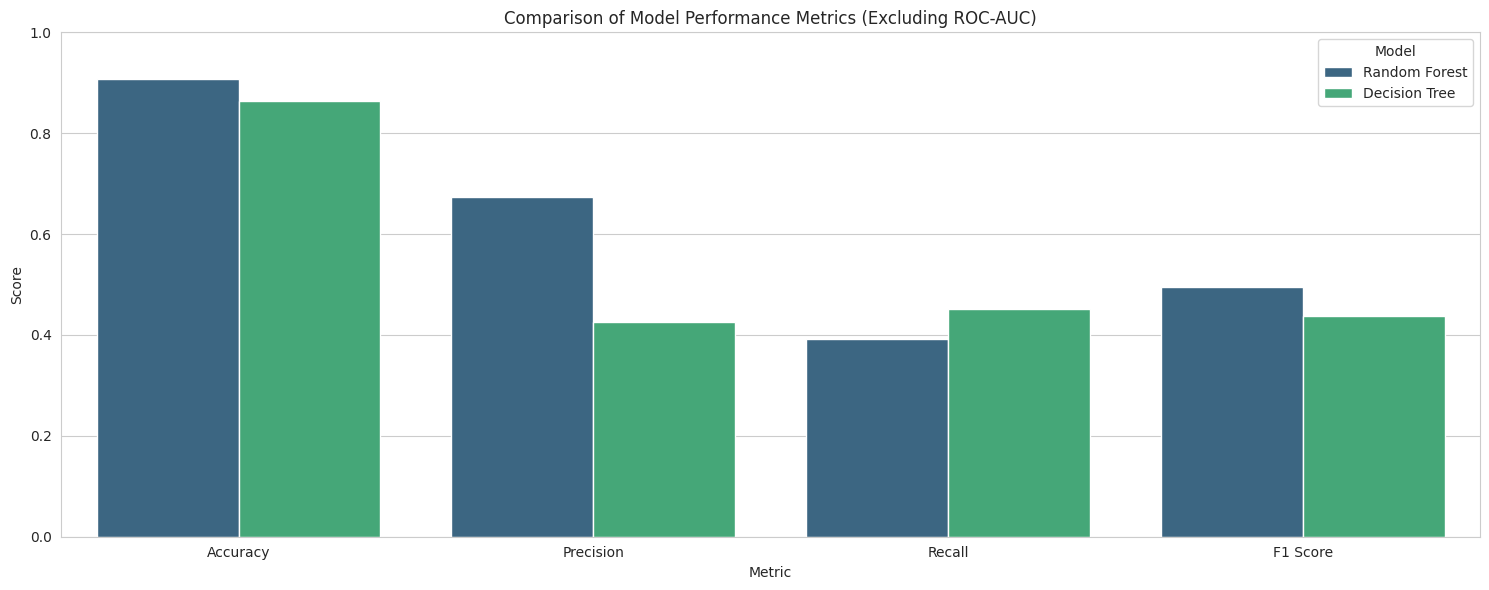

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted = comparison_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Filter out 'ROC-AUC' to plot separately or handle differently if needed, for now plot all
# However, it's often better to plot ROC-AUC on its own due to its different scale
# Let's plot all performance metrics except ROC-AUC in one plot, and ROC-AUC separately for clarity

# Metrics to plot together
performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(15, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted[df_melted['Metric'].isin(performance_metrics)], palette='viridis')
plt.title('Comparison of Model Performance Metrics (Excluding ROC-AUC)')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.legend(title='Model')
plt.tight_layout()
plt.show()

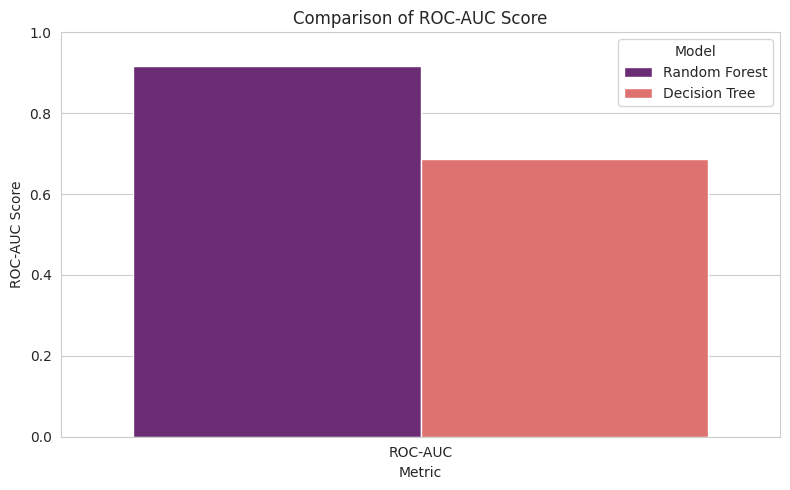

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted[df_melted['Metric'] == 'ROC-AUC'], palette='magma')
plt.title('Comparison of ROC-AUC Score')
plt.ylabel('ROC-AUC Score')
plt.ylim(0, 1) # ROC-AUC is also between 0 and 1
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset shape
print("Dataset shape:", df.shape)

# Summary statistics
print(df.describe())

Dataset shape: (45211, 17)
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous             y  
count  45211.000000  45211.000000  45211.000000  
mean      40.197828      0.580323      0.116985  
std      100.128746      2.303441      0.321406  
min       -1.000000      0.000000      0.000000  
25

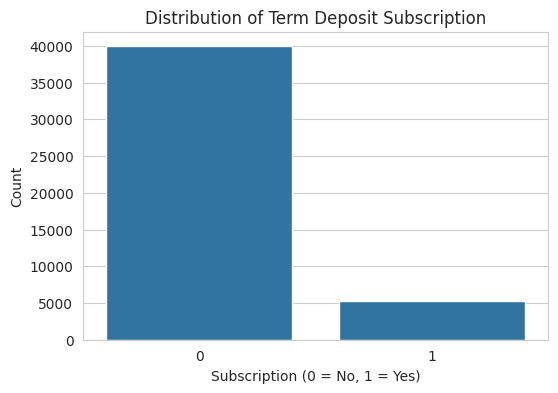

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscription (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

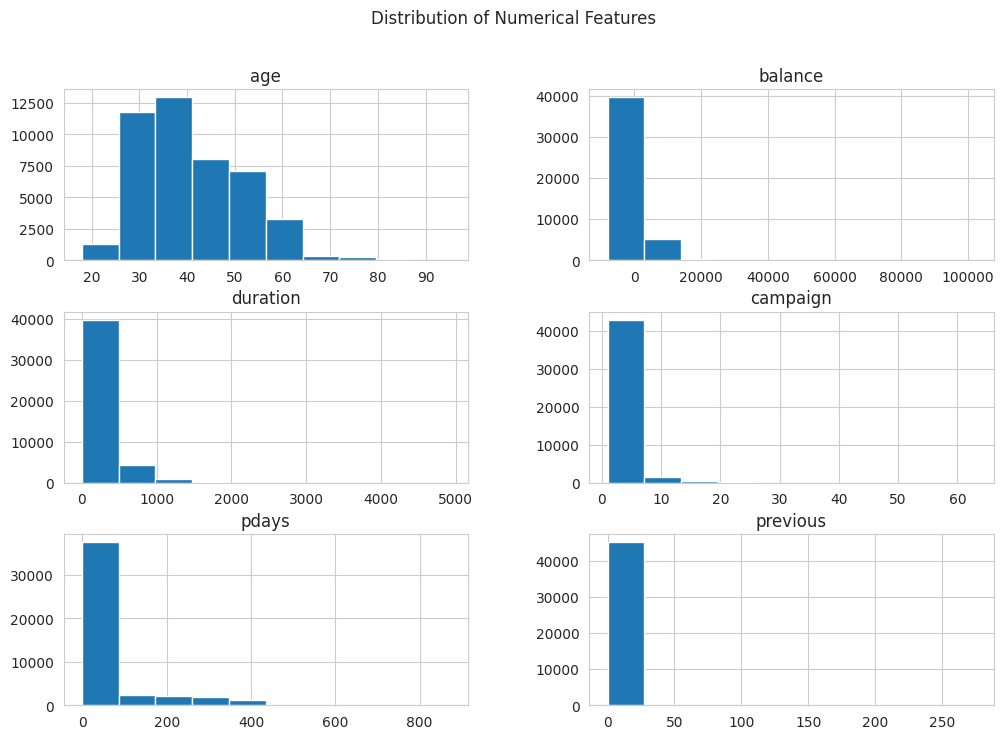

In [ ]:
numerical_features = ['age','balance','duration','campaign','pdays','previous']

df[numerical_features].hist(figsize=(12,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [ ]:
target_corr = corr_matrix['y'].sort_values(ascending=False)

print("Correlation with Target Variable:")
print(target_corr)

Correlation with Target Variable:
y                      1.000000
duration               0.394521
poutcome_success       0.306788
month_mar              0.129456
month_oct              0.128531
month_sep              0.123185
pdays                  0.103621
previous               0.093236
job_retired            0.079245
job_student            0.076897
month_dec              0.075164
education_tertiary     0.066448
marital_single         0.063526
balance                0.052838
month_feb              0.038417
job_management         0.032919
poutcome_other         0.031955
age                    0.025155
job_unemployed         0.020390
contact_telephone      0.014042
job_self-employed      0.000855
month_aug             -0.008536
month_jan             -0.008783
job_technician        -0.008970
month_nov             -0.014937
job_housemaid         -0.015195
month_jun             -0.016805
job_entrepreneur      -0.019662
default_yes           -0.022419
job_services          -0.027864
day   

In [ ]:
# Force target to binary
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print("Unique y_train:", y_train.unique())
print("Unique y_test:", y_test.unique())

Unique y_train: [0 2]
Unique y_test: [0 2]


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Unique predictions:", set(log_pred))

Unique predictions: {np.int64(0), np.int64(2)}


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert log_pred to binary (0 or 1) to match y_test
log_pred = (log_pred > 0).astype(int)

print("Logistic Regression Performance")

print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred, pos_label=1))
print("Recall:", recall_score(y_test, log_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, log_pred, pos_label=1))

Logistic Regression Performance
Accuracy: 0.8984850160345018
Precision: 0.6286764705882353
Recall: 0.32325141776937616
F1 Score: 0.42696629213483145


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.63      0.32      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

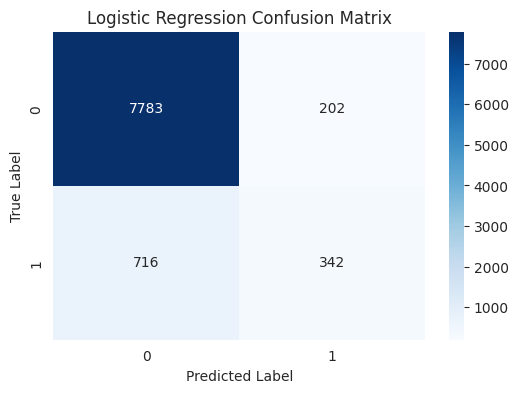

In [ ]:
cm_log = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
print("RF classes:", rf_model.classes_)
print("DT classes:", dt_model.classes_)
print("LogReg classes:", log_model.classes_)

RF classes: [0 2]
DT classes: [0 2]
LogReg classes: [0 2]


In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_pred = rf_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

In [ ]:
rf_pred = (rf_pred > 0).astype(int)
dt_pred = (dt_pred > 0).astype(int)

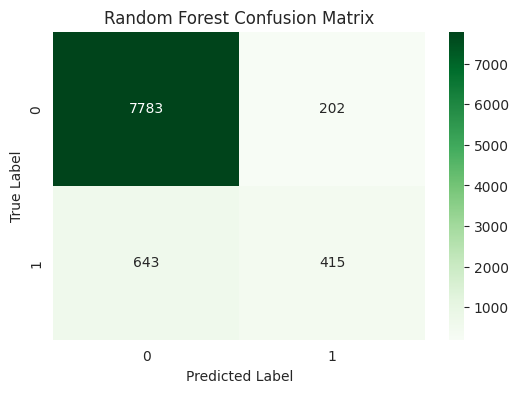

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

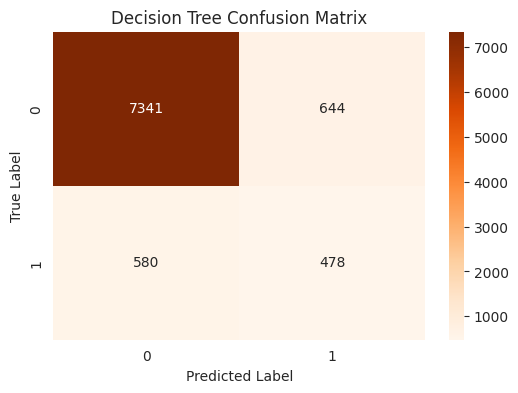

In [ ]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
y_test = (y_test > 0).astype(int)

In [ ]:
print(set(rf_pred))
print(set(dt_pred))
print(set(y_test))

{np.int64(0), np.int64(1)}
{np.int64(0), np.int64(1)}
{0, 1}


In [ ]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

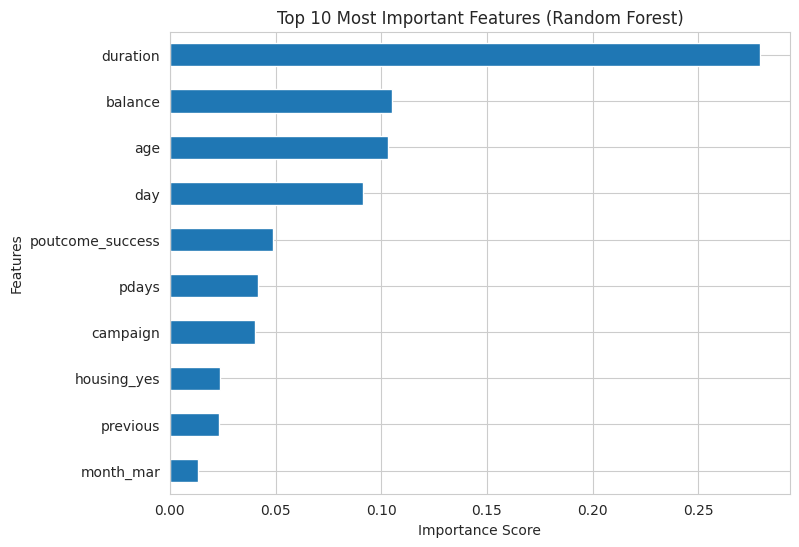

In [ ]:
plt.figure(figsize=(8,6))

feature_importance.head(10).plot(kind='barh')

plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

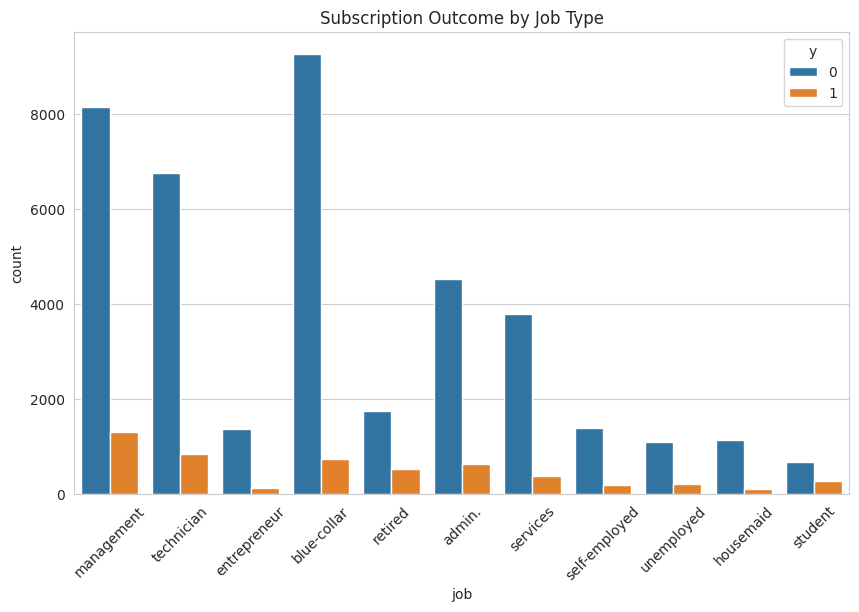

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='job', hue='y', data=df)

plt.title("Subscription Outcome by Job Type")
plt.xticks(rotation=45)

plt.show()

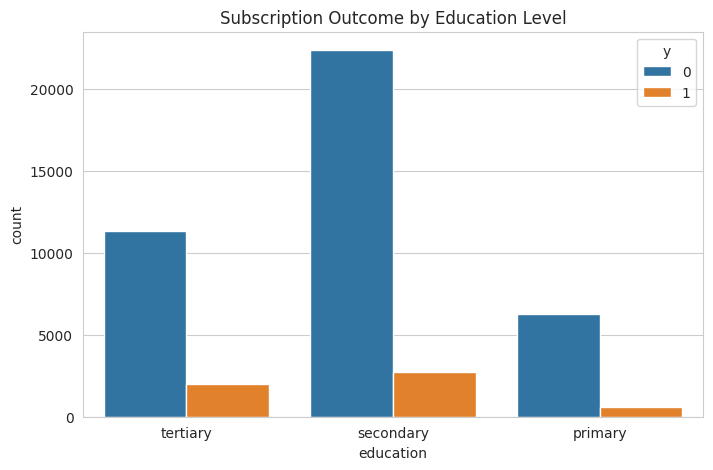

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='education', hue='y', data=df)

plt.title("Subscription Outcome by Education Level")

plt.show()

In [ ]:
# Logistic Regression metrics
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        log_accuracy,
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        log_precision,
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        log_recall,
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        log_f1,
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

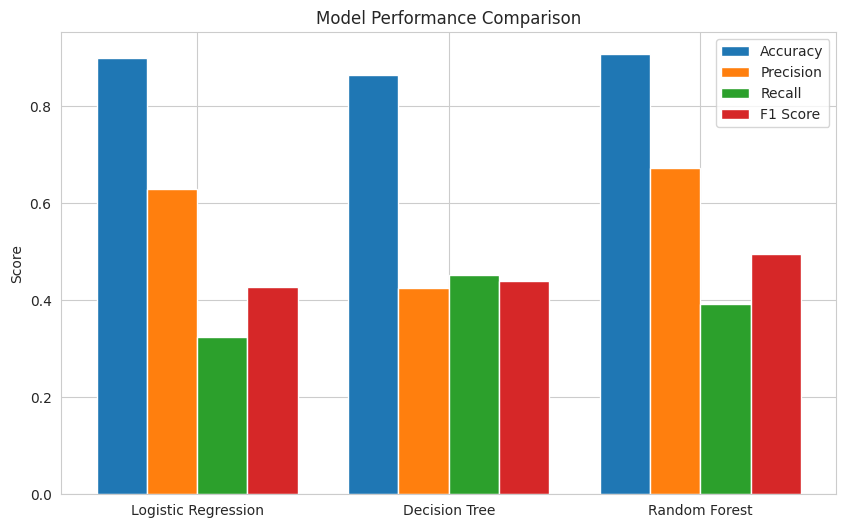

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# X positions
x = np.arange(len(results['Model']))
width = 0.2

plt.figure(figsize=(10,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results[metric], width, label=metric)

plt.xticks(x + width*1.5, results['Model'])

plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.show()

### Individual Model Performance Plots

/tmp/ipykernel_8538/2943401196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores.index, y=scores.values, palette='viridis')


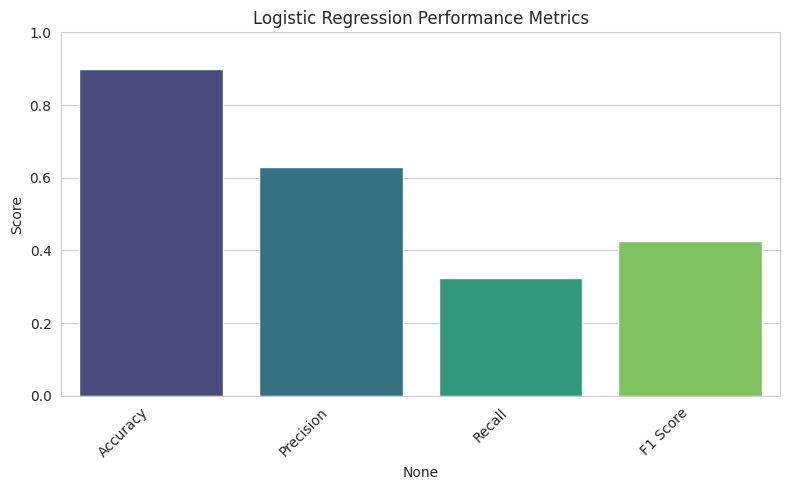

/tmp/ipykernel_8538/2943401196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores.index, y=scores.values, palette='viridis')


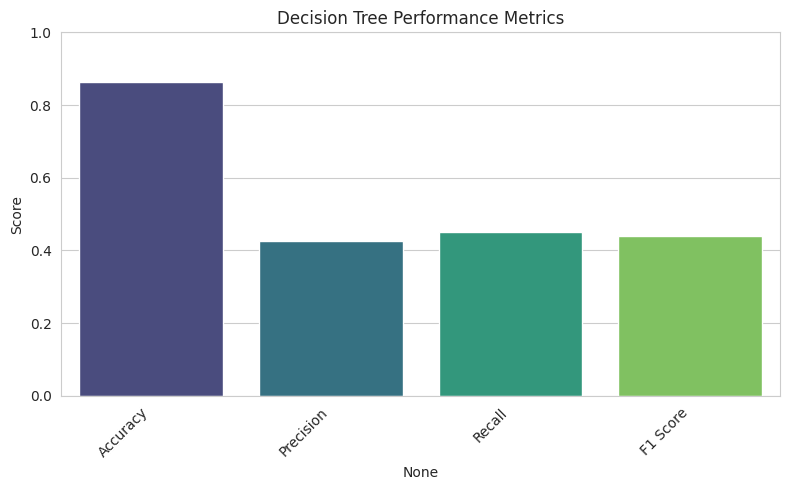

/tmp/ipykernel_8538/2943401196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores.index, y=scores.values, palette='viridis')


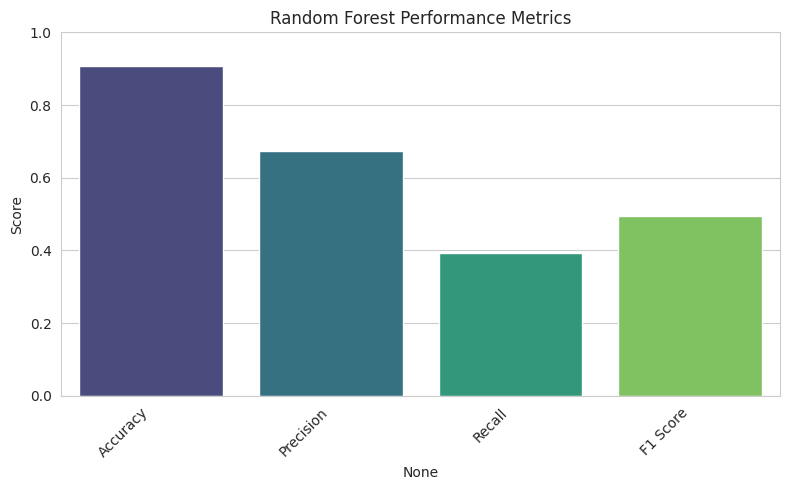

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for index, row in results.iterrows():
    model_name = row['Model']
    scores = row[metrics]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=scores.index, y=scores.values, palette='viridis')
    plt.title(f'{model_name} Performance Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1) # Metrics are usually between 0 and 1
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [ ]:
print("===== Model Comparison Table =====")
print(results)

print("\n===== Full Correlation Matrix =====")
print(corr_matrix)

===== Model Comparison Table =====
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.898485   0.628676  0.323251  0.426966
1        Decision Tree  0.864647   0.426025  0.451796  0.438532
2        Random Forest  0.906558   0.672609  0.392250  0.495522

===== Full Correlation Matrix =====
                          age   balance       day  duration  campaign  \
age                  1.000000  0.097783 -0.009120 -0.004648  0.004760   
balance              0.097783  1.000000  0.004503  0.021560 -0.014578   
day                 -0.009120  0.004503  1.000000 -0.030206  0.162490   
duration            -0.004648  0.021560 -0.030206  1.000000 -0.084570   
campaign             0.004760 -0.014578  0.162490 -0.084570  1.000000   
pdays               -0.023758  0.003435 -0.093044 -0.001565 -0.088628   
previous             0.001288  0.016674 -0.051710  0.001203 -0.032855   
y                    0.025155  0.052838 -0.028348  0.394521 -0.073172   
job_blue-collar